In [10]:

from itertools import islice

import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
import numpy as np
import torch
from torchvision.utils import make_grid

from maskvar.datasets.coco_lvis import LvisDataset
from maskvar.datasets.hqseg44k import HQSeg44KTrainDataset, HQSeg44KTestDataset
from maskvar.datasets.mask_level_dataset import MaskLevelDataset, MaskLevelDatasetRandom
from maskvar.datasets import instance_info

In [11]:
device = 'cuda:0'

In [12]:
def visualize_mask(image, layers, instances_info, alpha=0.5):
    plt.imshow(image // 2)
    # for inst_id, inst_info in instances_info.items():   
    #     if inst_info.parent is None:
    #         masked_data = np.ma.masked_where(layers[:, :, inst_info.mapping[0]] == 0, layers[:, :, inst_info.mapping[0]])
    #         plt.imshow(masked_data, alpha=alpha)
    for l in range(layers.shape[-1]):
        masked_data = np.ma.masked_where(layers[:, :, l] == 0, layers[:, :, l])
        plt.imshow(masked_data, alpha=alpha, cmap='tab20c')
    plt.show()

In [13]:
# dataset = HQSeg44KTrainDataset(
#     data_root='data/sam-hq',
#     img_size=(256, 256)
# )
dataset = LvisDataset(
    dataset_path='../data/coco_lvis',
    split='train',
    img_split='train',
    stuff_prob=0.0,
)

mask_level_dataset = MaskLevelDatasetRandom(dataset, sam_encoder=None, with_image_embed=False, device=device, seed=42, infinite=True, mask_filter_thresh=0.2)

torch.Size([25, 3, 256, 256]) torch.Size([25, 3, 256, 256])


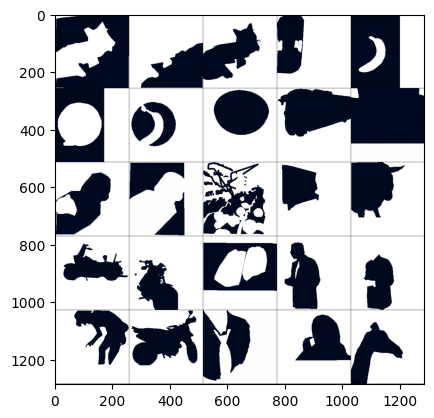

In [14]:
data_iter = iter(mask_level_dataset)

masks = []
images = []
for i, data in enumerate(islice(data_iter, 25)):
    image, _, _, mask = data # (C=3, H, W) and (1, H, W)
    # expand mask from (C=1, H, W) to (C=3, H, W)
    mask = mask.expand(3, -1, -1)
    masks.append(mask)
    images.append(image)

images_tensor = torch.stack(images)
masks_tensor = torch.stack(masks)

images_tensor = F.interpolate(images_tensor, size=(256, 256), mode='bilinear', align_corners=False)

print(images_tensor.shape, masks_tensor.shape)

vis_mask = images_tensor * masks_tensor + (1 - masks_tensor) * 0.5

chw = make_grid(vis_mask, nrow=5, padding=1, normalize=True, scale_each=True)
hwc = chw.permute(1, 2, 0).cpu().numpy()
plt.imshow(hwc)